# Lunar Lander - PCA Analysis

In [8]:
import re
import ijson
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded.')

Libraries loaded.


#### 1. Loading Data

In [9]:
DATA_PATH = 'test_data.json'

state_pat  = re.compile(
    r'x=([\-\d.]+), y=([\-\d.]+), vx=([\-\d.]+), vy=([\-\d.]+), '
    r'angle=([\-\d.]+), angular_vel=([\-\d.]+), '
    r'left_leg=([\-\d.]+), right_leg=([\-\d.]+)'
)
action_pat = re.compile(r'Action: (\d)')

rows = []
with open(DATA_PATH, 'rb') as f:
    for item in ijson.items(f, 'item'):
        convs = item['conversations']
        sm = state_pat.search(convs[0]['value'])
        am = action_pat.search(convs[1]['value'])
        if sm and am:
            rows.append((
                float(sm.group(1)), float(sm.group(2)),
                float(sm.group(3)), float(sm.group(4)),
                float(sm.group(5)), float(sm.group(6)),
                float(sm.group(7)), float(sm.group(8)),
                int(am.group(1))
            ))

FEATURES = ['x', 'y', 'vx', 'vy', 'angle', 'angular_vel', 'left_leg', 'right_leg']
df = pd.DataFrame(rows, columns=FEATURES + ['action'])
print(f'Loaded {len(df):,} samples')
df.head()

Loaded 100,000 samples


,x,y,vx,vy,angle,angular_vel,left_leg,right_leg,action
0,-0.2604,0.4123,0.2983,-0.5007,-0.3904,0.3068,0.0,0.0,2
1,-0.1041,-0.0257,0.1005,-0.0394,-0.0944,-0.2793,1.0,1.0,1
2,-0.2489,0.5318,0.1368,-0.4802,-0.3378,0.1880,0.0,0.0,1
3,0.0905,-0.0063,-0.0567,0.0172,0.0437,-0.0580,0.0,1.0,0
4,0.2905,0.2192,-0.1317,-0.3938,0.2388,-0.0737,0.0,0.0,2


### 2. Standardize & PCA

In [10]:
X = df[FEATURES].values
y = df['action'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print('PCA fit complete.')
print('Explained variance ratios:')
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {v:.3f}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.3f})')

# PC1 = 0.36 * angle + 0.22 * angular_vel + 0.14 * x + 0.09 * vy + ...    

PCA fit complete.
Explained variance ratios:
  PC1: 0.369  (cumulative: 0.369)
  PC2: 0.224  (cumulative: 0.592)
  PC3: 0.146  (cumulative: 0.738)
  PC4: 0.093  (cumulative: 0.831)
  PC5: 0.060  (cumulative: 0.891)
  PC6: 0.043  (cumulative: 0.934)
  PC7: 0.038  (cumulative: 0.973)
  PC8: 0.027  (cumulative: 1.000)


### 3. Explained Variance

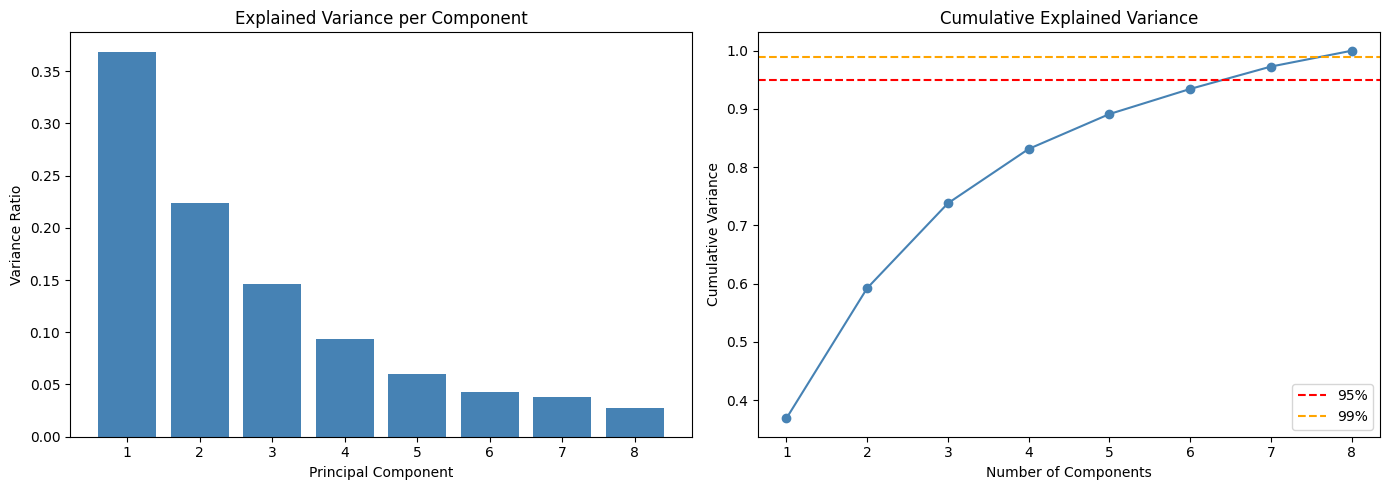

In [11]:
n = len(FEATURES)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, n+1), pca.explained_variance_ratio_, color='steelblue')
axes[0].set_title('Explained Variance per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Ratio')
axes[0].set_xticks(range(1, n+1))

axes[1].plot(range(1, n+1), np.cumsum(pca.explained_variance_ratio_), marker='o', color='steelblue')
axes[1].axhline(0.95, color='red', linestyle='--', label='95%')
axes[1].axhline(0.99, color='orange', linestyle='--', label='99%')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_xticks(range(1, n+1))
axes[1].legend()

plt.tight_layout()
plt.show()

### 4. Biplot — PC1 vs PC2 + Loading Vectors

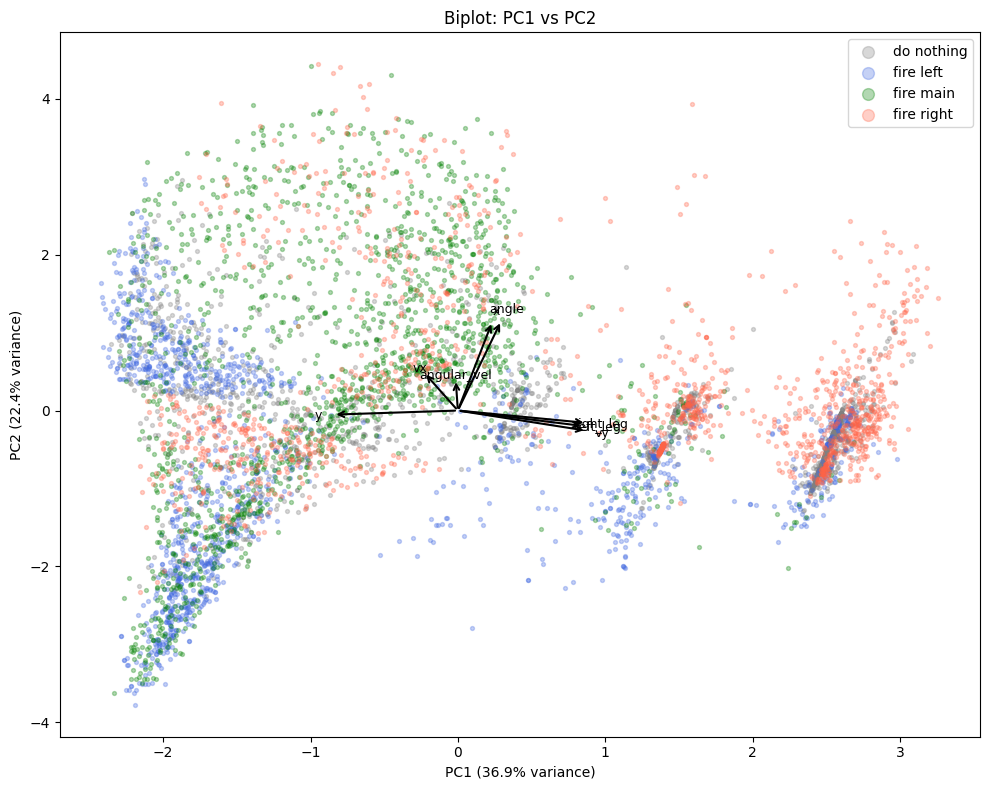

vy             0.492025
right_leg      0.490934
left_leg       0.479621
y              0.474843
angle          0.165906
x              0.131550
vx             0.128401
angular_vel    0.008105
Name: PC1, dtype: float64
*********************************************
angle          0.648486
x              0.641369
vx             0.273499
angular_vel    0.225523
vy             0.145336
left_leg       0.111871
right_leg      0.089173
y              0.029334
Name: PC2, dtype: float64


In [17]:
action_labels = {0: 'do nothing', 1: 'fire left', 2: 'fire main', 3: 'fire right'}
colors_map    = {0: 'gray',       1: 'royalblue', 2: 'green',     3: 'tomato'}

rng = np.random.default_rng(42)
viz_idx = rng.choice(len(X_pca), size=min(6000, len(X_pca)), replace=False)

fig, ax = plt.subplots(figsize=(10, 8))
for action_id, color in colors_map.items():
    mask = y[viz_idx] == action_id
    ax.scatter(X_pca[viz_idx[mask], 0], X_pca[viz_idx[mask], 1],
               c=color, alpha=0.3, s=8, label=action_labels[action_id])

# Loading vektörleri (scale ile)
scale = np.abs(X_pca[viz_idx, :2]).max() * 0.4
for i, feat in enumerate(FEATURES):
    ax.annotate('', xy=(pca.components_[0, i]*scale, pca.components_[1, i]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(pca.components_[0, i]*scale*1.12, pca.components_[1, i]*scale*1.12,
            feat, fontsize=9, ha='center', va='center', color='black')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Biplot: PC1 vs PC2')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()
print(loadings['PC1'].abs().sort_values(ascending=False))
print("*********************************************")
print(loadings['PC2'].abs().sort_values(ascending=False))